<a href="https://colab.research.google.com/github/Mdawood1122/Sales-Data-dashBoard-Python-Base/blob/main/Sales-Data-DashBoard-Python-Base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales-Data-DashBoard-Python-Base

This is a project I built to practice working with pandas and matplotlib. The idea was to take some sales data and actually make sense of it using Python instead of Excel.

I wanted to answer a few questions:
- Which products are selling the most?
- Which region brings in the highest sales?
- How do sales change week to week?

Since I didn't have a real dataset, I generated one using numpy.

## Step 1 — Imports

Standard stuff. I'm using pandas for the data, numpy to generate it, and matplotlib + seaborn for the charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style="whitegrid")

## Step 2 — Creating the Dataset

I used `np.random` to generate 180 rows of fake sales data. Each row has a date, a product name, a region, and a sales number.

I set a seed so the data stays the same every time I run the notebook — otherwise the charts would look different each run.

In [2]:
np.random.seed(1993)

products = ["Laptop", "Mobile", "Tablet", "Headphones", "Camera"]
regions = ["North", "South", "East", "West", "Central"]

df = pd.DataFrame({
    "Date": pd.date_range(start="2025-01-01", periods=180, freq="D"),
    "Product": np.random.choice(products, 180),
    "Region": np.random.choice(regions, 180),
    "Sales": np.random.randint(500, 5000, 180)
})

df["Month"] = df["Date"].dt.month_name()
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df.to_csv("sales_data.csv", index=False)
print("Dataset saved. Shape:", df.shape)

Dataset saved. Shape: (180, 6)


## Step 3 — Exploring the Data

Before jumping into charts, I always like to look at the data first. Just checking the shape, types, and a quick summary.

In [3]:
df = pd.read_csv("sales_data.csv")

print(df.head())
print("\nShape:", df.shape)
# df.info()  # ran this earlier to check dtypes

print("\nBasic stats:")
print(df["Sales"].describe())

         Date     Product   Region  Sales    Month  Week
0  2025-01-01      Mobile    South    587  January     1
1  2025-01-02      Mobile     East   1633  January     1
2  2025-01-03      Mobile  Central   4997  January     1
3  2025-01-04      Mobile    North    929  January     1
4  2025-01-05  Headphones    North   3036  January     1

Shape: (180, 6)

Basic stats:
count     180.000000
mean     2806.500000
std      1360.545271
min       517.000000
25%      1590.250000
50%      2909.000000
75%      4102.250000
max      4997.000000
Name: Sales, dtype: float64


## Step 4 — Sales by Product

First chart: total sales grouped by product. I used a bar chart here and added value labels on top of each bar.

The `get_height()` part took me a while to figure out — I didn't know you could loop over bars like that to place text.

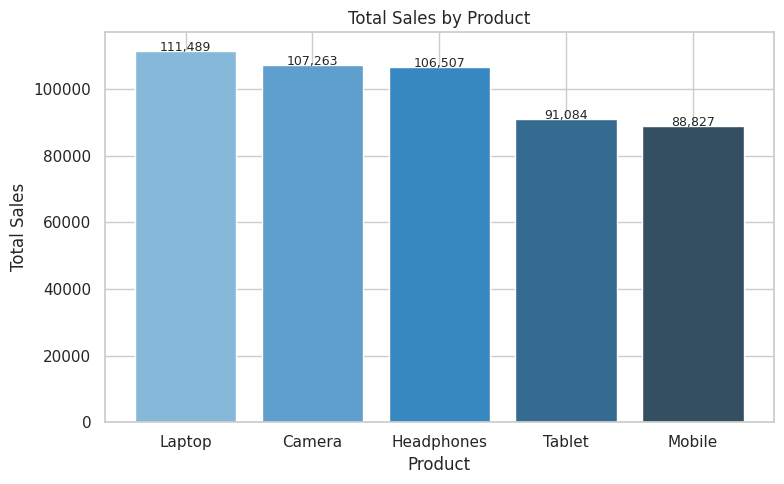

Best selling product: Laptop


In [4]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(product_sales.index, product_sales.values, color=sns.color_palette("Blues_d", len(product_sales)))

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=9
    )

ax.set_title("Total Sales by Product")
ax.set_xlabel("Product")
ax.set_ylabel("Total Sales")
plt.tight_layout()
plt.show()

print("Best selling product:", product_sales.idxmax())

## Step 5 — Sales by Region

Same idea but broken down by region. I wanted to see if one region is clearly dominating.

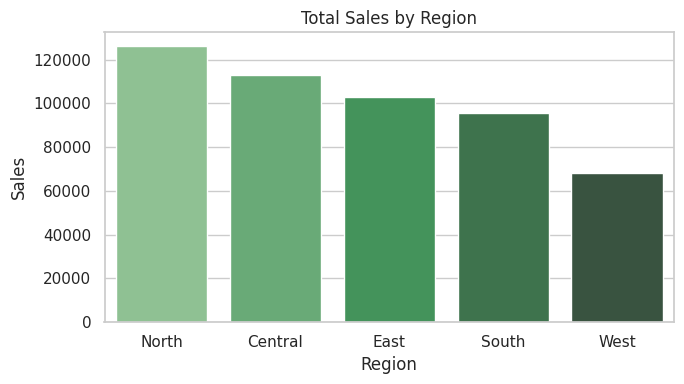

Top region: North


In [5]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette="Greens_d",
    legend=False,
    ax=ax
)

ax.set_title("Total Sales by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

print("Top region:", region_sales.idxmax())

## Step 6 — Weekly Sales Trend

I was curious if sales go up or down over time. This line chart shows total sales per week across the whole dataset.

The shaded area is just a visual touch — I used `fill_between` to make it look a bit nicer.

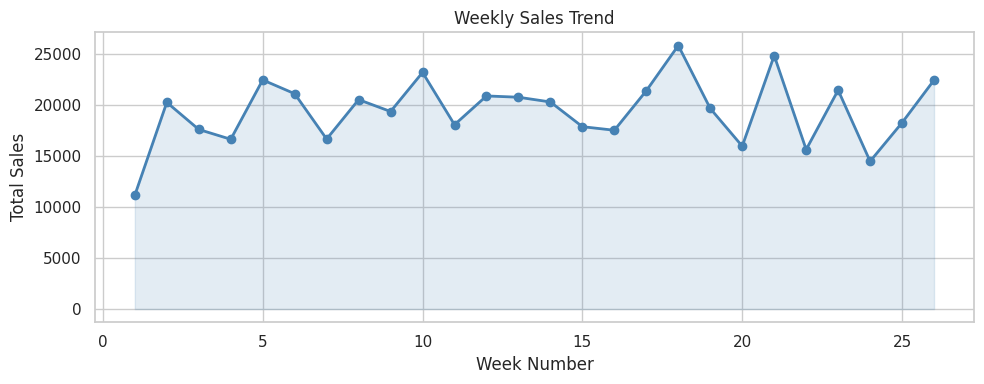

In [6]:
weekly = df.groupby("Week")["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly["Week"], weekly["Sales"], marker="o", color="steelblue", linewidth=2)
ax.fill_between(weekly["Week"], weekly["Sales"], alpha=0.15, color="steelblue")

ax.set_title("Weekly Sales Trend")
ax.set_xlabel("Week Number")
ax.set_ylabel("Total Sales")
plt.tight_layout()
plt.show()

## Step 7 — Region vs Product Heatmap

This was the most interesting chart to build. I used `pivot_table` to reshape the data so I could plot a heatmap showing which product sells most in which region.

The `annot=True` and `fmt=","` options were new to me — they put formatted numbers inside each cell.

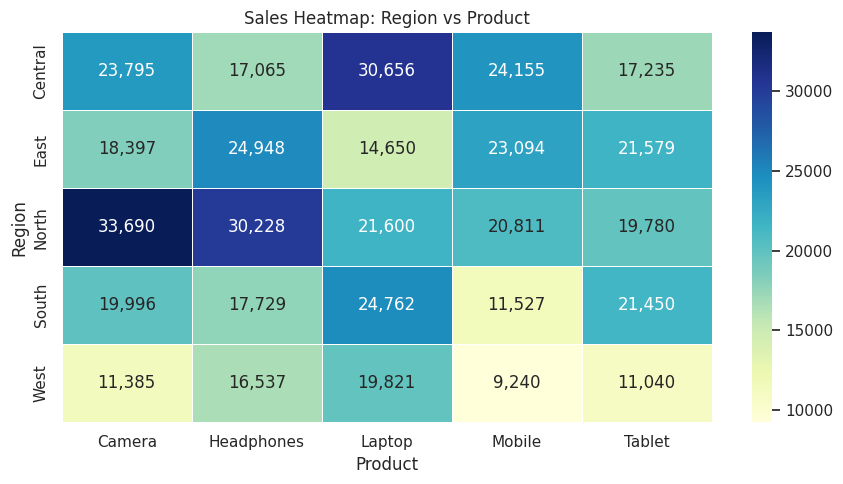

In [7]:
pivot = df.pivot_table(values="Sales", index="Region", columns="Product", aggfunc="sum")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=",", cmap="YlGnBu", linewidths=0.5, ax=ax)

ax.set_title("Sales Heatmap: Region vs Product")
plt.tight_layout()
plt.show()

## Step 8 — Summary Table

Finally, I grouped by both Region and Product to get a full breakdown. I also exported it to a CSV so it can be shared or opened in Excel.

In [8]:
summary = df.groupby(["Region", "Product"])["Sales"].agg(["sum", "mean", "count"])
summary.columns = ["Total Sales", "Avg Sale", "Transactions"]
summary = summary.sort_values("Total Sales", ascending=False)

print(summary.head(10))
summary.to_csv("sales_summary.csv")
print("\nSummary exported to sales_summary.csv")

                    Total Sales     Avg Sale  Transactions
Region  Product                                           
North   Camera            33690  3369.000000            10
Central Laptop            30656  3406.222222             9
North   Headphones        30228  3778.500000             8
East    Headphones        24948  2772.000000             9
South   Laptop            24762  2751.333333             9
Central Mobile            24155  3019.375000             8
        Camera            23795  3399.285714             7
East    Mobile            23094  2566.000000             9
North   Laptop            21600  3085.714286             7
East    Tablet            21579  3082.714286             7

Summary exported to sales_summary.csv


## What I Learned

A few things I picked up while building this:

- `pivot_table` is way more useful than I thought once you understand the `index` and `columns` arguments
- Looping over matplotlib bars with `get_height()` is a nice trick for adding labels
- `fill_between` makes line charts look much cleaner
- `dt.isocalendar().week` is how you get the week number from a date — `.dt.week` is deprecated

Next I want to try this with a real dataset, maybe something from Kaggle.

In [9]:
print("Done!")
print(f"Total rows: {len(df)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total sales: {df['Sales'].sum():,}")

Done!
Total rows: 180
Date range: 2025-01-01 to 2025-06-29
Total sales: 505,170
